In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",None)

In [2]:
dataset = pd.read_csv(r"C:\Users\Dell\Downloads\HR_file.csv")
dataset

# Problem statement is based on the independent variable 
# we have to check the dependent variable that is the employee will Quit the company or not

,Satisfaction Level,Last Evaluation,Number of Projects,Monthly Hours,Total Time at the Company,Work Accidents,Quit the Company,Promoted in Last 5 yrs,Departments,salary,Management
0,0.38,0.53,2,157,3,0,1,0,sales,low,31
1,0.80,0.86,5,262,6,0,1,0,sales,medium,71
2,0.11,0.88,7,272,4,0,1,0,sales,medium,8
3,0.72,0.87,5,223,5,0,1,0,sales,low,68
4,0.37,0.52,2,159,3,0,1,0,sales,low,48
...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low,49
14995,0.37,0.48,2,160,3,0,1,0,support,low,3
14996,0.37,0.53,2,143,3,0,1,0,support,low,5
14997,0.11,0.96,6,280,4,0,1,0,support,low,78


In [3]:
dataset.head()

,Satisfaction Level,Last Evaluation,Number of Projects,Monthly Hours,Total Time at the Company,Work Accidents,Quit the Company,Promoted in Last 5 yrs,Departments,salary,Management
0,0.38,0.53,2,157,3,0,1,0,sales,low,31
1,0.80,0.86,5,262,6,0,1,0,sales,medium,71
2,0.11,0.88,7,272,4,0,1,0,sales,medium,8
3,0.72,0.87,5,223,5,0,1,0,sales,low,68
4,0.37,0.52,2,159,3,0,1,0,sales,low,48


In [4]:
dataset.shape

(14999, 11)

In [5]:
dataset.describe(include='all')

,Satisfaction Level,Last Evaluation,Number of Projects,Monthly Hours,Total Time at the Company,Work Accidents,Quit the Company,Promoted in Last 5 yrs,Departments,salary,Management
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999,14999.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316,NaN
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN,11.706780
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN,25.300786
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Satisfaction Level         14999 non-null  float64
 1   Last Evaluation            14999 non-null  float64
 2   Number of Projects         14999 non-null  int64  
 3   Monthly Hours              14999 non-null  int64  
 4   Total Time at the Company  14999 non-null  int64  
 5   Work Accidents             14999 non-null  int64  
 6   Quit the Company           14999 non-null  int64  
 7   Promoted in Last 5 yrs     14999 non-null  int64  
 8   Departments                14999 non-null  object 
 9   salary                     14999 non-null  object 
 10  Management                 14999 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 1.3+ MB


# Data Preprocessing

In [7]:
dataset.duplicated().sum()

1463

In [8]:
dataset.drop_duplicates(inplace=True, keep='first')
dataset.shape

(13536, 11)

In [9]:
dataset.columns

Index(['Satisfaction Level', 'Last Evaluation', 'Number of Projects',
       'Monthly Hours', 'Total Time at the Company', 'Work Accidents',
       'Quit the Company', 'Promoted in Last 5 yrs', 'Departments ', 'salary',
       'Management'],
      dtype='object')

In [10]:
dataset.drop(['Work Accidents', 'Management'], axis=1, inplace=True)

In [11]:
dataset.shape

(13536, 9)

In [12]:
dataset.isnull().sum()

Satisfaction Level           0
Last Evaluation              0
Number of Projects           0
Monthly Hours                0
Total Time at the Company    0
Quit the Company             0
Promoted in Last 5 yrs       0
Departments                  0
salary                       0
dtype: int64

In [13]:
for i in dataset.columns:
    print({i:dataset[i].unique()})

{'Satisfaction Level': array([0.38, 0.8 , 0.11, 0.72, 0.37, 0.41, 0.1 , 0.92, 0.89, 0.42, 0.45,
       0.84, 0.36, 0.78, 0.76, 0.09, 0.46, 0.4 , 0.82, 0.87, 0.57, 0.43,
       0.13, 0.44, 0.39, 0.85, 0.81, 0.9 , 0.74, 0.79, 0.17, 0.24, 0.91,
       0.71, 0.86, 0.14, 0.75, 0.7 , 0.31, 0.73, 0.83, 0.32, 0.54, 0.27,
       0.77, 0.88, 0.48, 0.19, 0.6 , 0.12, 0.61, 0.33, 0.56, 0.47, 0.28,
       0.55, 0.53, 0.59, 0.66, 0.25, 0.34, 0.58, 0.51, 0.35, 0.64, 0.5 ,
       0.23, 0.15, 0.49, 0.3 , 0.63, 0.21, 0.62, 0.29, 0.2 , 0.16, 0.65,
       0.68, 0.67, 0.22, 0.26, 0.99, 0.98, 1.  , 0.52, 0.93, 0.97, 0.69,
       0.94, 0.96, 0.18, 0.95])}
{'Last Evaluation': array([0.53, 0.86, 0.88, 0.87, 0.52, 0.5 , 0.77, 0.85, 1.  , 0.54, 0.81,
       0.92, 0.55, 0.56, 0.47, 0.99, 0.51, 0.89, 0.83, 0.95, 0.57, 0.49,
       0.46, 0.62, 0.94, 0.48, 0.8 , 0.74, 0.7 , 0.78, 0.91, 0.93, 0.98,
       0.97, 0.79, 0.59, 0.84, 0.45, 0.96, 0.68, 0.82, 0.9 , 0.71, 0.6 ,
       0.65, 0.58, 0.72, 0.67, 0.75, 0.73, 0.63,

In [14]:
dataset['Total Time at the Company'].value_counts()

Total Time at the Company
3     5885
2     2931
4     2392
5     1405
6      641
10     107
7       94
8       81
Name: count, dtype: int64

<Axes: xlabel='Total Time at the Company', ylabel='count'>

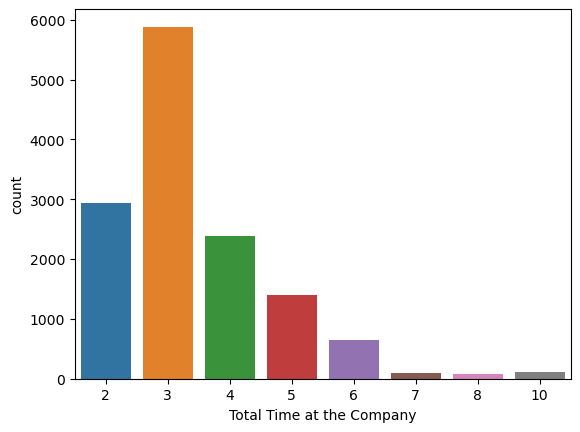

In [15]:
sns.countplot(x=dataset['Total Time at the Company'], data=dataset)

In [16]:
dataset.groupby(['Departments ','Quit the Company'])['salary'].count()/len(dataset)*100

Departments   Quit the Company
IT            0                    6.043144
              1                    1.987293
RandD         0                    4.499113
              1                    0.893913
accounting    0                    3.782506
              1                    1.499704
hr            0                    3.605201
              1                    1.580969
management    0                    2.836879
              1                    0.664894
marketing     0                    4.144504
              1                    1.470154
product_mng   0                    4.255319
              1                    1.455378
sales         0                   19.865544
              1                    7.402482
support       0                   11.148050
              1                    4.048463
technical     0                   13.696809
              1                    5.119681
Name: salary, dtype: float64

In [17]:
dataset.groupby(['salary','Quit the Company'])['Satisfaction Level'].count()/len(dataset)*100

salary  Quit the Company
high    0                    6.959220
        1                    0.605792
low     0                   33.732270
        1                   15.846631
medium  0                   33.185579
        1                    9.670508
Name: Satisfaction Level, dtype: float64

(array([1271.,  441.,  442., 1707., 1289., 1556., 1559., 1892., 1807.,
        1572.]),
 array([0.09 , 0.181, 0.272, 0.363, 0.454, 0.545, 0.636, 0.727, 0.818,
        0.909, 1.   ]),
 <BarContainer object of 10 artists>)

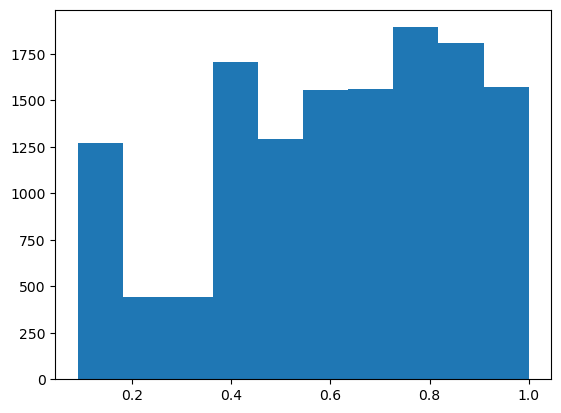

In [18]:
plt.hist(x = dataset['Satisfaction Level'],
        bins = 10
)

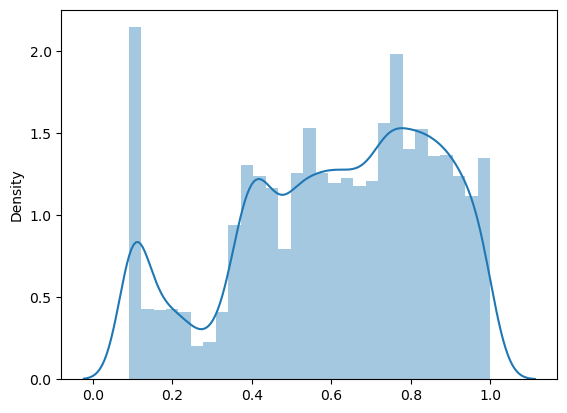

In [19]:
sns.distplot(x = dataset['Satisfaction Level']);

In [20]:
dataset.groupby(['Total Time at the Company','Quit the Company']).count()/len(dataset)*100

Satisfaction Level  \
Total Time at the Company Quit the Company                       
2                         0                          21.269208   
                          1                           0.384161   
3                         0                          31.885343   
                          1                          11.591312   
4                         0                          11.155437   
                          1                           6.515957   
5                         0                           4.284870   
                          1                           6.094858   
6                         0                           3.198877   
                          1                           1.536643   
7                         0                           0.694444   
8                         0                           0.598404   
10                        0                           0.790485   

                                            Last Evaluation  \
Total Time at the Company Quit the Company                    
2                         0                       21.269208   
                          1                        0.384161   
3                         0                       31.885343   
                          1                       11.591312   
4                         0                       11.155437   
                          1                        6.515957   
5                         0                        4.284870   
                          1                        6.094858   
6                         0                        3.198877   
                          1                        1.536643   
7                         0                        0.694444   
8                         0                        0.598404   
10                        0                        0.790485   

                                            Number of Projects  Monthly Hours  \
Total Time at the Company Quit the Company                                      
2                         0                          21.269208      21.269208   
                          1                           0.384161       0.384161   
3                         0                          31.885343      31.885343   
                          1                          11.591312      11.591312   
4                         0                          11.155437      11.155437   
                          1                           6.515957       6.515957   
5                         0                           4.284870       4.284870   
                          1                           6.094858       6.094858   
6                         0                           3.198877       3.198877   
                          1                           1.536643       1.536643   
7                         0                           0.694444       0.694444   
8                         0                           0.598404       0.598404   
10                        0                           0.790485       0.790485   

                                            Promoted in Last 5 yrs  \
Total Time at the Company Quit the Company                           
2                         0                              21.269208   
                          1                               0.384161   
3                         0                              31.885343   
                          1                              11.591312   
4                         0                              11.155437   
                          1                               6.515957   
5                         0                               4.284870   
                          1                               6.094858   
6                         0                               3.198877   
                          1                               1.536643   
7                         0                        

In [21]:
pd.crosstab(index=dataset['Promoted in Last 5 yrs'],columns=dataset['Quit the Company'])/len(dataset)*100

# 0 = Stay and 1 = Quit

Quit the Company,0,1
Promoted in Last 5 yrs,,
0,72.436466,25.982565
1,1.440603,0.140366


In [22]:
from sklearn.preprocessing import LabelEncoder

le_dept = LabelEncoder()

dataset['Departments '] = le_dept.fit_transform(dataset['Departments '])

le_name_mapping = dict(zip(le_dept.classes_, le_dept.transform(le_dept.classes_)))

print('mapping', le_name_mapping)

mapping {'IT': 0, 'RandD': 1, 'accounting': 2, 'hr': 3, 'management': 4, 'marketing': 5, 'product_mng': 6, 'sales': 7, 'support': 8, 'technical': 9}


In [23]:
le_sal = LabelEncoder()

dataset['salary'] = le_sal.fit_transform(dataset['salary'])

le_name_mapping = dict(zip(le_sal.classes_, le_sal.transform(le_sal.classes_)))

print('mapping', le_name_mapping)

mapping {'high': 0, 'low': 1, 'medium': 2}


In [24]:
dataset

,Satisfaction Level,Last Evaluation,Number of Projects,Monthly Hours,Total Time at the Company,Quit the Company,Promoted in Last 5 yrs,Departments,salary
0,0.38,0.53,2,157,3,1,0,7,1
1,0.80,0.86,5,262,6,1,0,7,2
2,0.11,0.88,7,272,4,1,0,7,2
3,0.72,0.87,5,223,5,1,0,7,1
4,0.37,0.52,2,159,3,1,0,7,1
...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,1,0,8,1
14995,0.37,0.48,2,160,3,1,0,8,1
14996,0.37,0.53,2,143,3,1,0,8,1
14997,0.11,0.96,6,280,4,1,0,8,1


In [25]:
dataset['Quit the Company'].value_counts()

Quit the Company
0    10000
1     3536
Name: count, dtype: int64

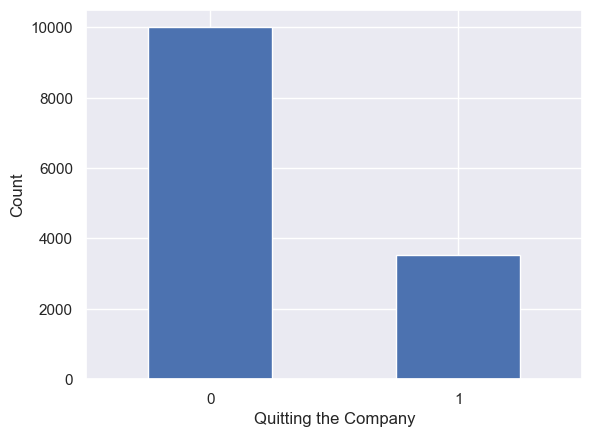

In [26]:
sns.set()

Quit_plot = dataset['Quit the Company'].value_counts().plot(kind='bar')

plt.xlabel('Quitting the Company')
plt.ylabel('Count')
plt.xticks(rotation=360)

plt.show()

In [ ]:
# x_features = ['Satisfaction Level', 'Last Evaluation', 'Number of Projects',
# 'Monthly Hours', 'Total Time at the Company', 'Promoted in Last 5 yrs', 'Departments', 'salary']

In [27]:
X = dataset.drop(['Quit the Company'], axis = 1)

Y = dataset['Quit the Company']

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X)

X = scaler.transform(X)

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3,
                                                    random_state=0)

In [30]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(9475, 8)
(9475,)
(4061, 8)
(4061,)


In [31]:
from sklearn.tree import DecisionTreeClassifier

model_DecisionTree = DecisionTreeClassifier(criterion="entropy", random_state=0)

model_DecisionTree.fit(X_train, Y_train)

Y_pred = model_DecisionTree.predict(X_test)

In [32]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm = confusion_matrix(Y_test, Y_pred)
print(cfm)

print("Classification report: ")
print(classification_report(Y_test, Y_pred))

acc = accuracy_score(Y_test, Y_pred)
print("Accuracy of the model: ", acc)

[[2973   56]
 [  29 1003]]
Classification report: 
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3029
           1       0.95      0.97      0.96      1032

    accuracy                           0.98      4061
   macro avg       0.97      0.98      0.97      4061
weighted avg       0.98      0.98      0.98      4061

Accuracy of the model:  0.979069194779611


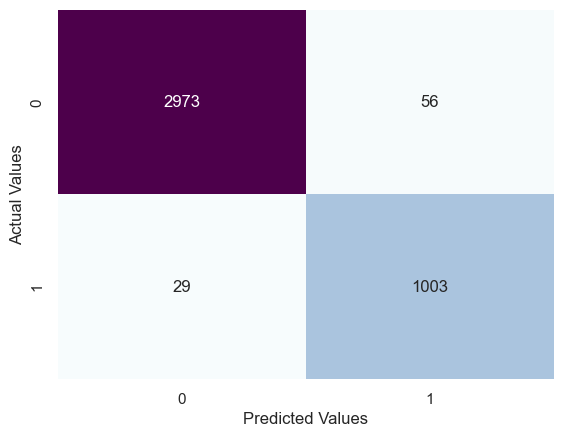

In [33]:
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')

plt.show()

In [34]:
model_DecisionTree.score(X_train, Y_train)

1.0

In [35]:
print(list(zip(dataset.columns[0:-1], model_DecisionTree.feature_importances_)))

[('Satisfaction Level', 0.3519882075996864), ('Last Evaluation', 0.12664643916781823), ('Number of Projects', 0.17535936486969525), ('Monthly Hours', 0.10961193148703322), ('Total Time at the Company', 0.2112483819267433), ('Quit the Company', 0.0010919107925562608), ('Promoted in Last 5 yrs', 0.017577131050803527), ('Departments ', 0.006476633105663845)]


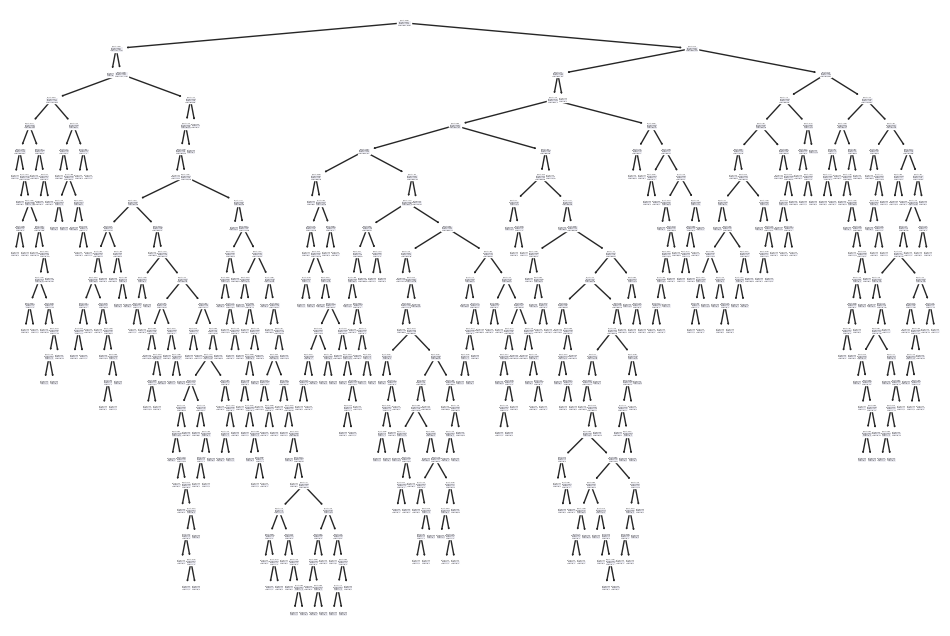

In [36]:
plt.figure(figsize=(12,8))

from sklearn import tree

tree.plot_tree(model_DecisionTree.fit(X_train, Y_train));

In [37]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression()

classifier.fit(X_train, Y_train)

Y_pred = classifier.predict(X_test)

print(Y_pred)

[0 0 0 ... 0 0 0]


In [39]:
Y_pred_prob = classifier.predict_proba(X_test)

Y_pred_prob

array([[0.85275929, 0.14724071],
       [0.89400892, 0.10599108],
       [0.77329059, 0.22670941],
       ...,
       [0.62133407, 0.37866593],
       [0.82023105, 0.17976895],
       [0.90992395, 0.09007605]])

In [38]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm = confusion_matrix(Y_test, Y_pred)
print(cfm)

print("Classification report: ")
print(classification_report(Y_test, Y_pred))

acc = accuracy_score(Y_test, Y_pred)
print("Accuracy of the model: ", acc)

[[2761  268]
 [ 765  267]]
Classification report: 
              precision    recall  f1-score   support

           0       0.78      0.91      0.84      3029
           1       0.50      0.26      0.34      1032

    accuracy                           0.75      4061
   macro avg       0.64      0.59      0.59      4061
weighted avg       0.71      0.75      0.71      4061

Accuracy of the model:  0.7456291553804482


In [40]:
print(list(zip(Y_test, Y_pred)))

[(0, 0), (1, 0), (0, 0), (0, 0), (0, 1), (0, 0), (0, 0), (0, 0), (1, 0), (0, 0), (0, 0), (1, 1), (0, 0), (0, 0), (1, 1), (0, 0), (0, 0), (0, 0), (0, 0), (1, 1), (0, 0), (0, 0), (0, 1), (0, 0), (0, 0), (1, 0), (1, 0), (0, 0), (1, 0), (0, 1), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (1, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (1, 0), (0, 0), (0, 0), (1, 1), (0, 0), (1, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (1, 0), (0, 0), (0, 0), (1, 0), (0, 0), (0, 0), (0, 0), (1, 0), (0, 0), (0, 0), (1, 0), (0, 0), (0, 0), (0, 0), (0, 0), (1, 0), (0, 0), (0, 0), (1, 0), (1, 0), (0, 0), (0, 0), (1, 1), (0, 1), (0, 0), (0, 0), (1, 0), (1, 0), (0, 0), (1, 1), (0, 0), (0, 0), (0, 0), (1, 1), (0, 0), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (1, 1), (0, 0), (1, 1), (1, 0), (1, 0), (0, 0), (1, 0), (0, 0), (0, 1), (1, 0), (1, 0), (0, 0), (1, 0), (0, 0), (0, 0), (1, 0), (0, 0), (0, 0), (1, 0), (0, 0),

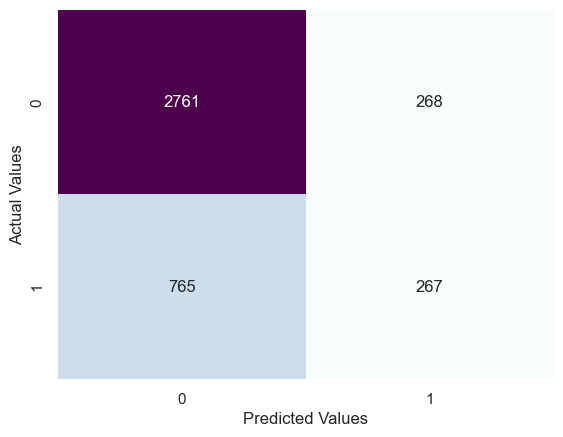

In [41]:
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')

plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')

plt.show()